# Diana Ruiz Moctezuma
## Telecom X — Análisis de Evasión de Clientes (Churn)
---
**Proyecto:** Challenge Data Science LATAM  
**Objetivo:** Identificar los factores que llevan a la cancelación del servicio y proporcionar insights estratégicos para reducir la tasa de evasión.

---
### Estructura del Notebook
1. **Extracción** — Carga de datos desde JSON/API
2. **Transformación** — Limpieza, normalización y nuevas variables
3. **Análisis Exploratorio (EDA)** — Visualizaciones y patrones
4. **Informe Final** — Conclusiones y recomendaciones


#📌 Extracción

In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cargar datos desde JSON (equivalente a la API)
with open('TelecomX_Data.json', 'r') as f:
    raw = json.load(f)

df = pd.json_normalize(raw)
print(f"Registros cargados: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
df.head(3)

Registros cargados: 7,267
Columnas: 21


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


#🔧 Transformación (ETL)

In [4]:
print("Tipos de datos:")
print(df.dtypes)
print(f"\nValores nulos:")
print(df.isnull().sum())
print(f"\nDuplicados: {df.duplicated().sum()}")

Tipos de datos:
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object

Valores nulos:
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents   

In [5]:
# Limpieza
# Corregir tipo: Charges.Total no debe ser string
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# Eliminar duplicados y nulos
df.drop_duplicates(inplace=True)
df.dropna(subset=['account.Charges.Total'], inplace=True)

# Nueva variable: cargo diario
df['Cuentas_Diarias'] = (df['account.Charges.Monthly'] / 30).round(4)

# Binaria para correlación
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

print(f"Shape final: {df.shape}")
print(f"\nChurn:\n{df['Churn'].value_counts()}")
print(f"\nTasa de evasión: {df['Churn_bin'].mean()*100:.2f}%")

Shape final: (7256, 23)

Churn:
Churn
No     5163
Yes    1869
        224
Name: count, dtype: int64

Tasa de evasión: 25.76%


#📊 Carga y análisis

In [6]:
desc = df[['customer.tenure', 'account.Charges.Monthly',
           'account.Charges.Total', 'Cuentas_Diarias']].describe().round(2)
print(desc)

       customer.tenure  account.Charges.Monthly  account.Charges.Total  \
count          7256.00                  7256.00                7256.00   
mean             32.40                    64.76                2280.63   
std              24.56                    30.13                2268.63   
min               1.00                    18.25                  18.80   
25%               9.00                    35.45                 400.22   
50%              29.00                    70.30                1391.00   
75%              55.00                    89.90                3785.30   
max              72.00                   118.75                8684.80   

       Cuentas_Diarias  
count          7256.00  
mean              2.16  
std               1.00  
min               0.61  
25%               1.18  
50%               2.34  
75%               3.00  
max               3.96  


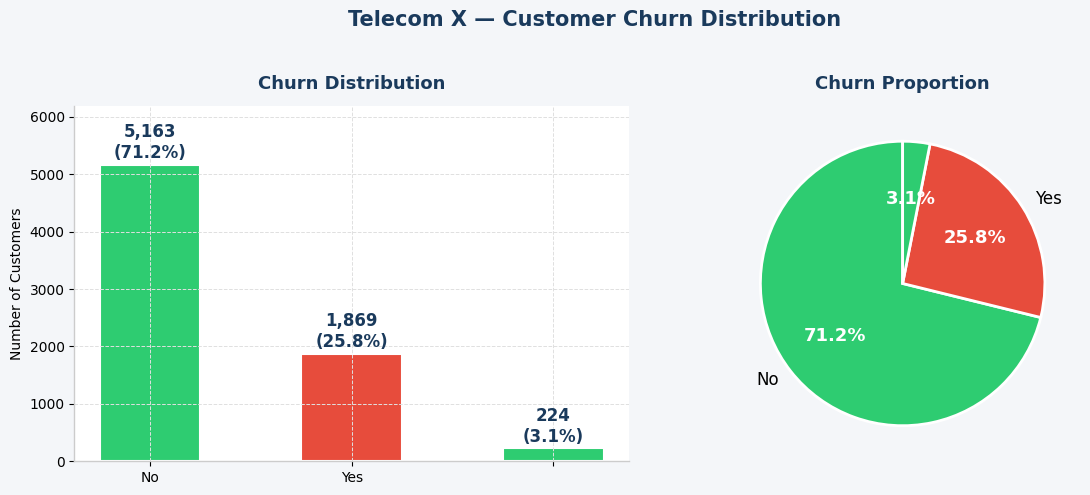

In [8]:
churn_cnt = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor(BG)

bars = ax1.bar(churn_cnt.index, churn_cnt.values,
               color=[GREEN, RED], width=0.5, edgecolor='white', linewidth=1.5)
for bar, pct in zip(bars, churn_pct.values):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
             f'{bar.get_height():,}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold', color=BLUE)
ax1.set_title('Churn Distribution', fontsize=13, fontweight='bold', color=BLUE, pad=12)
ax1.set_ylabel('Number of Customers', fontsize=10)
ax1.set_ylim(0, churn_cnt.max() * 1.2)

wedges, texts, autotexts = ax2.pie(
    churn_cnt.values, labels=churn_cnt.index, autopct='%1.1f%%',
    colors=[GREEN, RED], startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':12})
for at in autotexts:
    at.set_fontweight('bold'); at.set_color('white'); at.set_fontsize(13)
ax2.set_title('Churn Proportion', fontsize=13, fontweight='bold', color=BLUE, pad=12)

fig.suptitle('Telecom X — Customer Churn Distribution', fontsize=15, fontweight='bold', color=BLUE)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

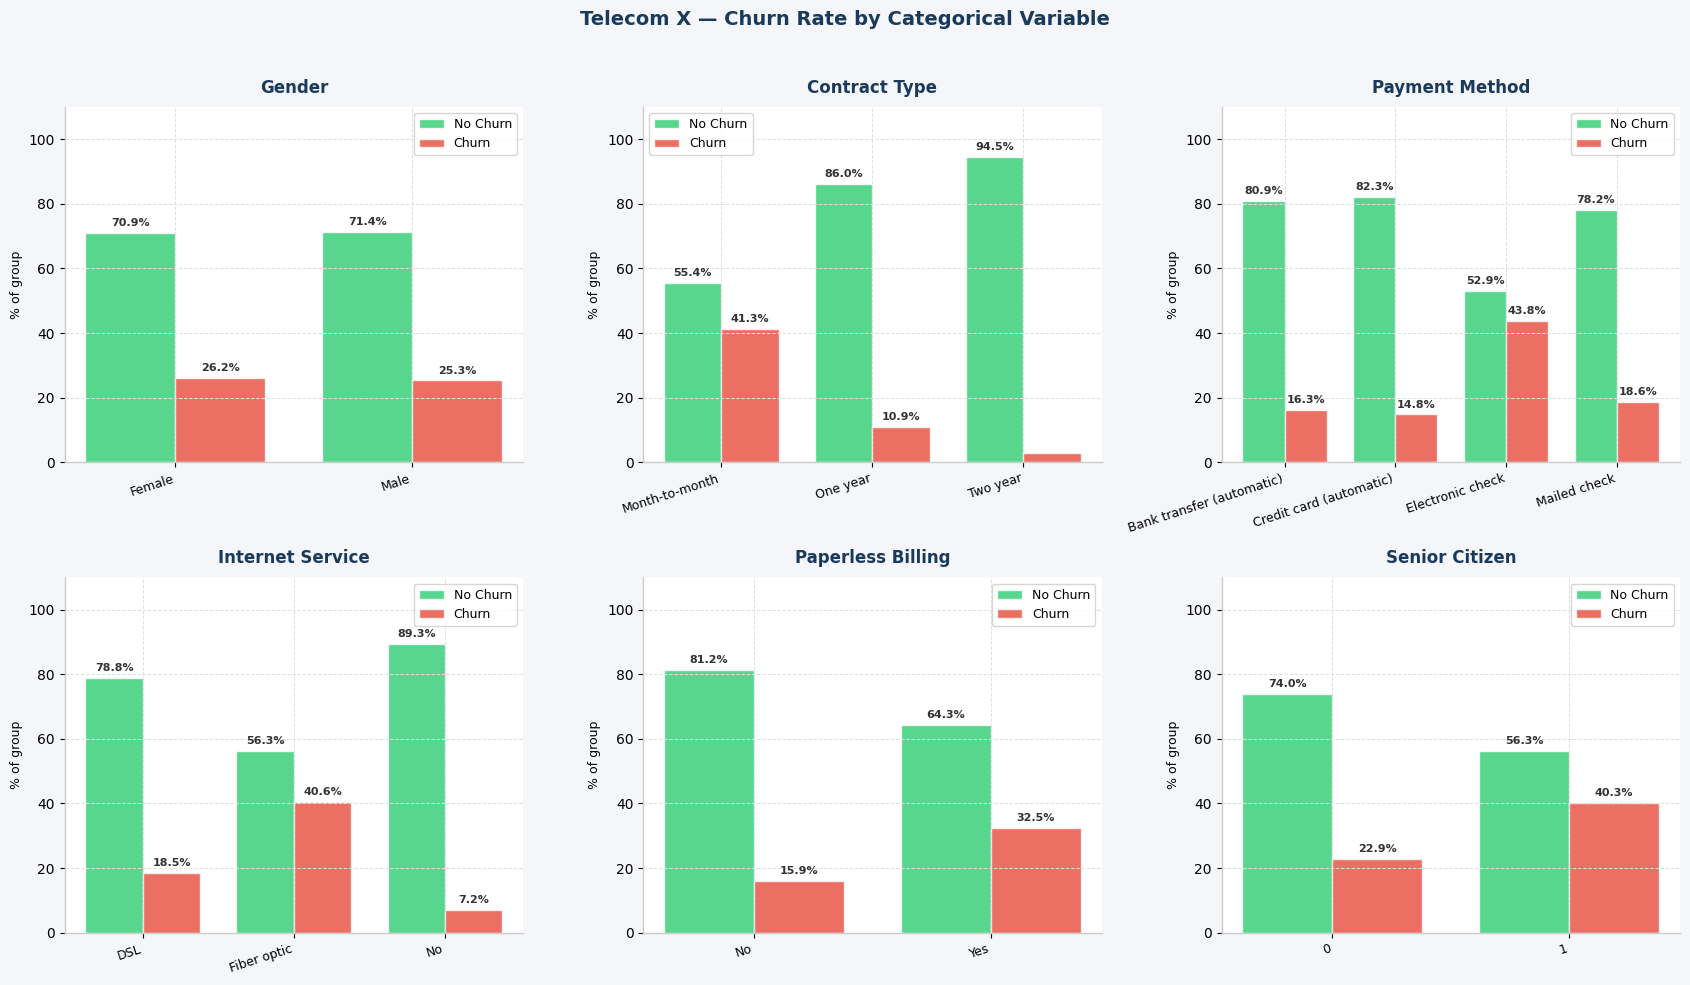

In [9]:
cat_vars = [
    ('customer.gender',          'Gender'),
    ('account.Contract',         'Contract Type'),
    ('account.PaymentMethod',    'Payment Method'),
    ('internet.InternetService', 'Internet Service'),
    ('account.PaperlessBilling', 'Paperless Billing'),
    ('customer.SeniorCitizen',   'Senior Citizen'),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
fig.patch.set_facecolor(BG)
axes = axes.flatten()

for ax, (col, label) in zip(axes, cat_vars):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct = ct.reindex(columns=['No','Yes'], fill_value=0)
    x = np.arange(len(ct)); w = 0.38
    b1 = ax.bar(x - w/2, ct['No'],  w, color=GREEN, alpha=0.8, edgecolor='white', label='No Churn')
    b2 = ax.bar(x + w/2, ct['Yes'], w, color=RED,   alpha=0.8, edgecolor='white', label='Churn')
    ax.set_xticks(x)
    ax.set_xticklabels(ct.index, rotation=18, ha='right', fontsize=9)
    ax.set_title(label, fontsize=12, fontweight='bold', color=BLUE, pad=10)
    ax.set_ylabel('% of group', fontsize=9)
    ax.set_ylim(0, 110)
    ax.legend(fontsize=9)
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        if h > 5:
            ax.text(bar.get_x()+bar.get_width()/2, h+1.5, f'{h:.1f}%',
                    ha='center', va='bottom', fontsize=8, fontweight='bold', color='#333')

fig.suptitle('Telecom X — Churn Rate by Categorical Variable', fontsize=14, fontweight='bold', color=BLUE)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

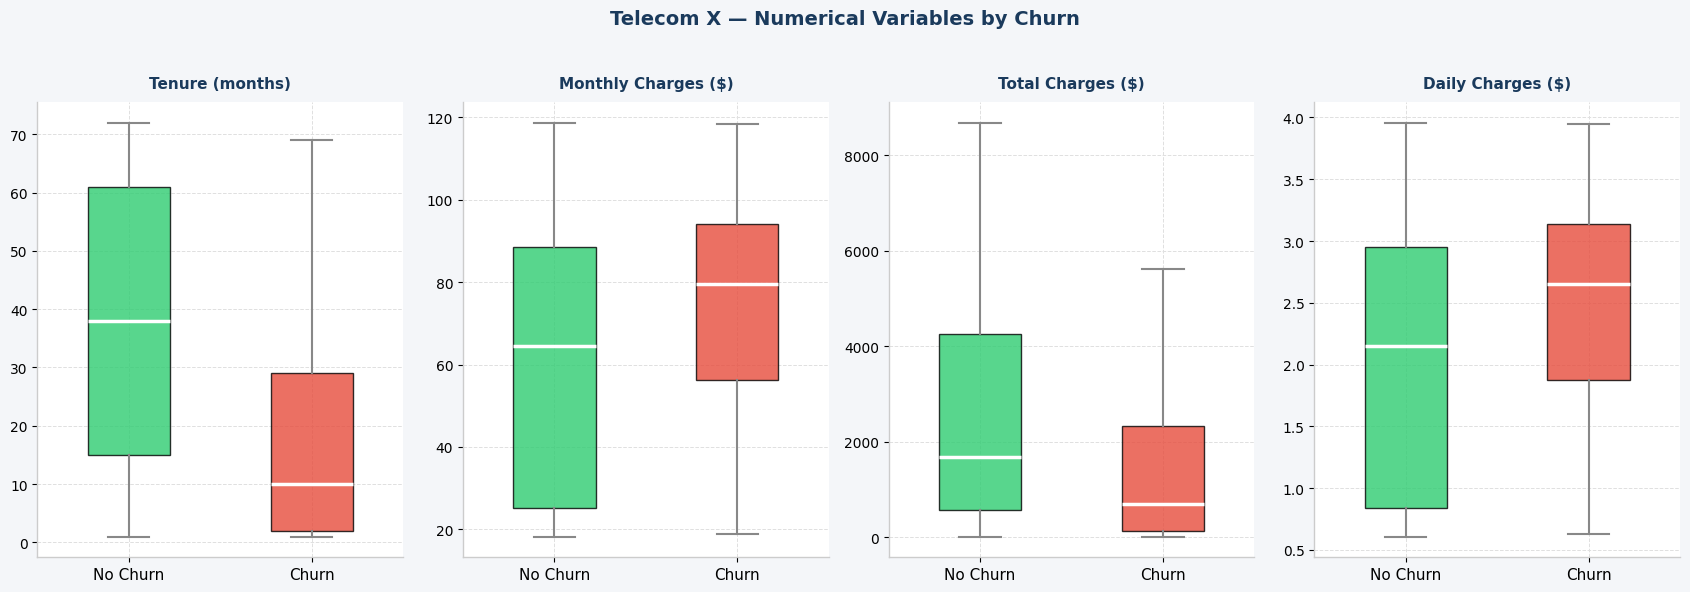

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(17, 6))
fig.patch.set_facecolor(BG)

num_vars = [
    ('customer.tenure',          'Tenure (months)'),
    ('account.Charges.Monthly',  'Monthly Charges ($)'),
    ('account.Charges.Total',    'Total Charges ($)'),
    ('Cuentas_Diarias',          'Daily Charges ($)'),
]
for ax, (col, label) in zip(axes, num_vars):
    d0 = df[df['Churn']=='No'][col].dropna()
    d1 = df[df['Churn']=='Yes'][col].dropna()
    bp = ax.boxplot([d0, d1], patch_artist=True, widths=0.45,
                    medianprops={'color':'white','linewidth':2.5},
                    whiskerprops={'linewidth':1.5,'color':'#888'},
                    capprops={'linewidth':1.5,'color':'#888'},
                    flierprops={'marker':'o','markersize':2.5,'alpha':0.2,'markeredgewidth':0})
    bp['boxes'][0].set_facecolor(GREEN); bp['boxes'][0].set_alpha(0.8)
    bp['boxes'][1].set_facecolor(RED);   bp['boxes'][1].set_alpha(0.8)
    ax.set_xticklabels(['No Churn','Churn'], fontsize=11)
    ax.set_title(label, fontsize=11, fontweight='bold', color=BLUE, pad=10)

fig.suptitle('Telecom X — Numerical Variables by Churn', fontsize=14, fontweight='bold', color=BLUE)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

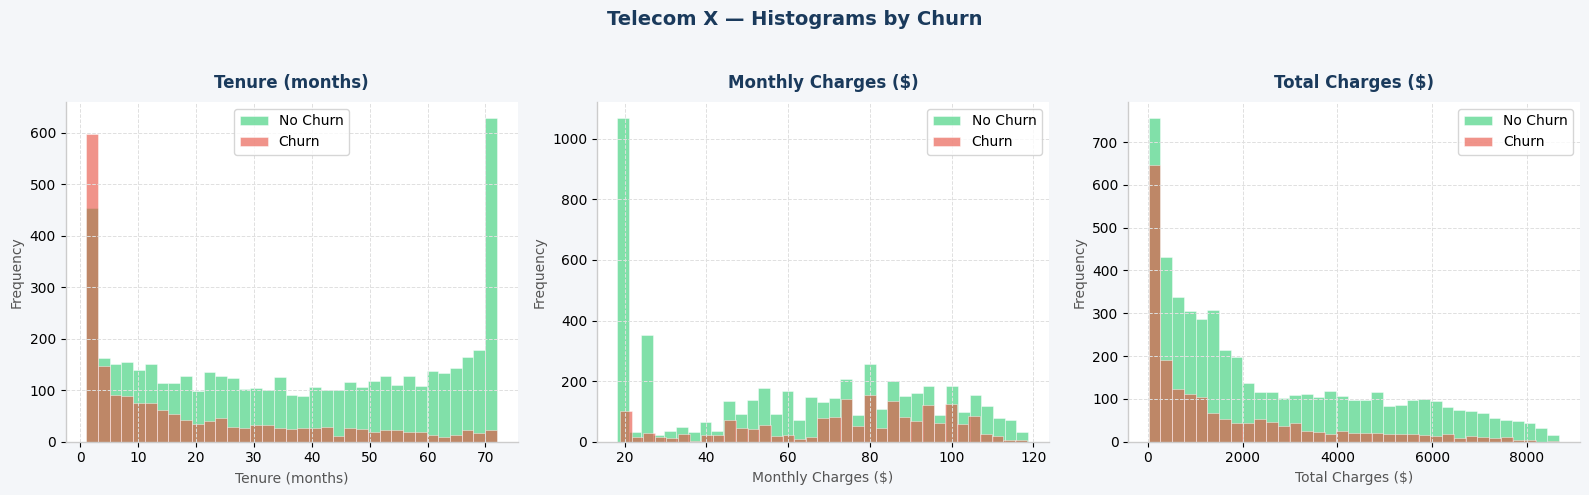

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG)

vars_ = [
    ('customer.tenure',          'Tenure (months)'),
    ('account.Charges.Monthly',  'Monthly Charges ($)'),
    ('account.Charges.Total',    'Total Charges ($)'),
]
for ax, (col, label) in zip(axes, vars_):
    ax.hist(df[df['Churn']=='No'][col].dropna(),  bins=35, alpha=0.6,
            color=GREEN, label='No Churn', edgecolor='white', linewidth=0.5)
    ax.hist(df[df['Churn']=='Yes'][col].dropna(), bins=35, alpha=0.6,
            color=RED, label='Churn', edgecolor='white', linewidth=0.5)
    ax.set_title(label, fontsize=12, fontweight='bold', color=BLUE, pad=10)
    ax.set_xlabel(label, fontsize=10, color='#555')
    ax.set_ylabel('Frequency', fontsize=10, color='#555')
    ax.legend(fontsize=10)

fig.suptitle('Telecom X — Histograms by Churn', fontsize=14, fontweight='bold', color=BLUE)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

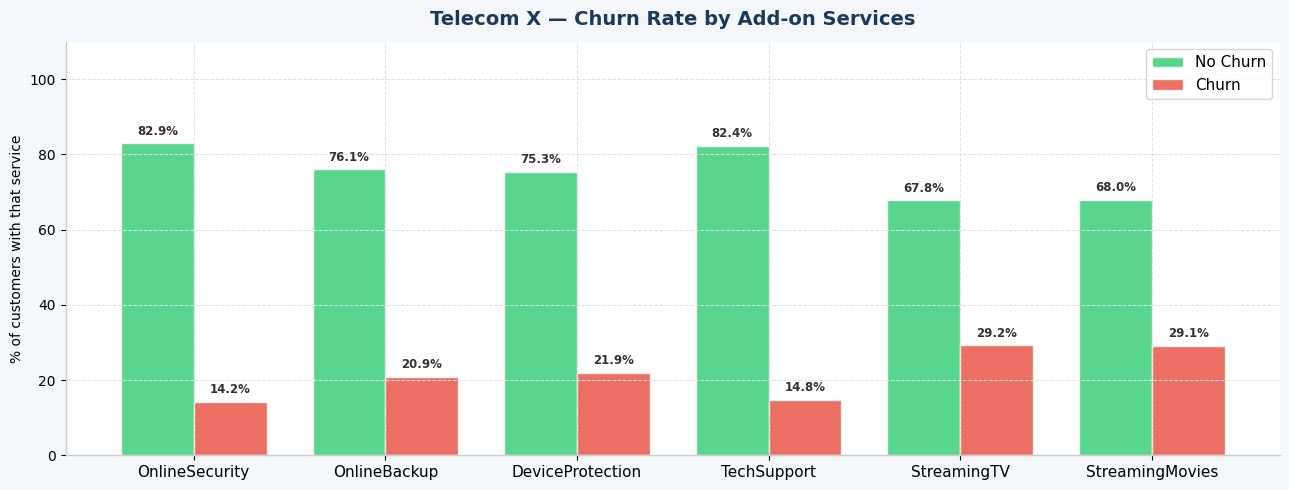

In [12]:
servicios = [
    ('internet.OnlineSecurity',  'OnlineSecurity'),
    ('internet.OnlineBackup',    'OnlineBackup'),
    ('internet.DeviceProtection','DeviceProtection'),
    ('internet.TechSupport',     'TechSupport'),
    ('internet.StreamingTV',     'StreamingTV'),
    ('internet.StreamingMovies', 'StreamingMovies'),
]
tasa_no, tasa_yes = [], []
for col, _ in servicios:
    sub = df[df[col]=='Yes']; tot = len(sub)
    tasa_no.append( len(sub[sub['Churn']=='No']) /tot*100 if tot else 0)
    tasa_yes.append(len(sub[sub['Churn']=='Yes'])/tot*100 if tot else 0)

x = np.arange(len(servicios)); w = 0.38
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(BG)
ax.bar(x - w/2, tasa_no,  w, color=GREEN, alpha=0.8, edgecolor='white', label='No Churn')
ax.bar(x + w/2, tasa_yes, w, color=RED,   alpha=0.8, edgecolor='white', label='Churn')
ax.set_xticks(x); ax.set_xticklabels([s[1] for s in servicios], fontsize=11)
ax.set_ylabel('% of customers with that service', fontsize=10)
ax.set_ylim(0, 110); ax.legend(fontsize=11)
for bar in ax.patches:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+1.5, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#333')
ax.set_title('Telecom X — Churn Rate by Add-on Services', fontsize=14, fontweight='bold', color=BLUE, pad=12)
plt.tight_layout()
plt.show()

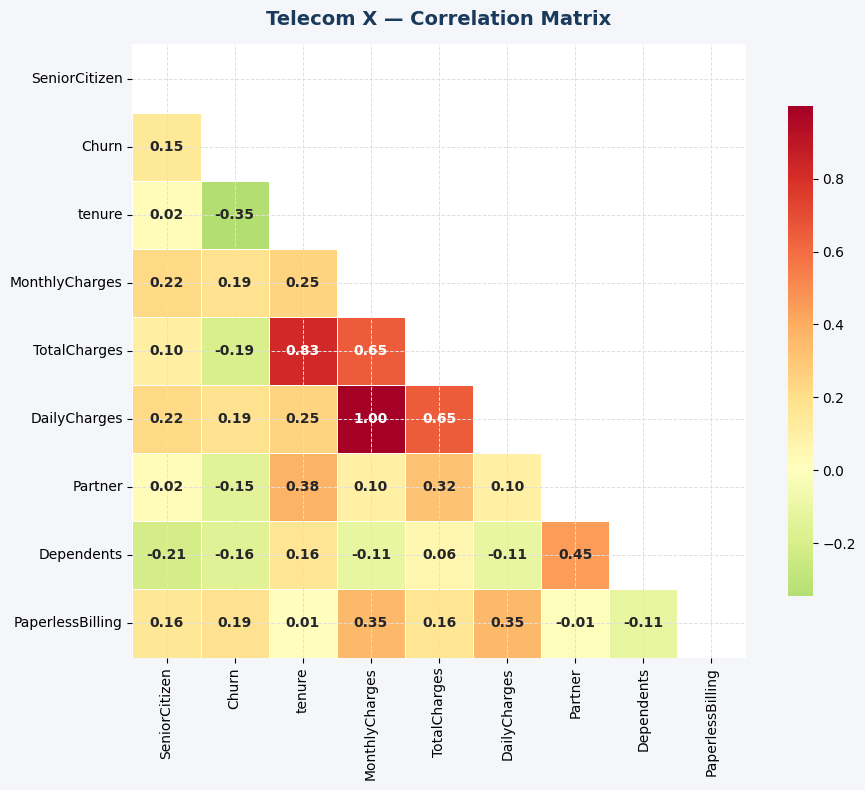

In [13]:
bin_cols = ['customer.SeniorCitizen','Churn_bin','customer.tenure',
            'account.Charges.Monthly','account.Charges.Total','Cuentas_Diarias']
for c, alias in [('customer.Partner','Partner_bin'),
                 ('customer.Dependents','Dependents_bin'),
                 ('account.PaperlessBilling','PaperlessBilling_bin')]:
    df[alias] = (df[c]=='Yes').astype(int)
    bin_cols.append(alias)

corr_df = df[bin_cols].rename(columns={
    'customer.SeniorCitizen':'SeniorCitizen', 'Churn_bin':'Churn',
    'customer.tenure':'tenure',
    'account.Charges.Monthly':'MonthlyCharges',
    'account.Charges.Total':'TotalCharges',
    'Cuentas_Diarias':'DailyCharges',
    'Partner_bin':'Partner', 'Dependents_bin':'Dependents',
    'PaperlessBilling_bin':'PaperlessBilling'})

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(BG)
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn_r', center=0, ax=ax, square=True,
            linewidths=0.5, annot_kws={'size':10,'weight':'bold'},
            cbar_kws={'shrink':0.8})
ax.set_title('Telecom X — Correlation Matrix', fontsize=14, fontweight='bold', color=BLUE, pad=14)
plt.tight_layout()
plt.show()

#📄Informe final

## 4. Informe Final

---

### Introducción

Telecom X enfrenta una **tasa de evasión del 26%**, lo que representa una pérdida significativa de ingresos recurrentes. Este análisis identifica los perfiles de mayor riesgo para orientar acciones estratégicas de retención.

---

### Limpieza y Tratamiento de Datos

La estructura JSON anidada fue aplanada con `pd.json_normalize()`. La columna `account.Charges.Total` se encontraba en formato string y fue convertida a `float`. Se eliminaron registros duplicados y 11 registros con valores nulos en `Charges.Total`. Adicionalmente se crearon dos nuevas variables: `Cuentas_Diarias` (`Charges.Monthly / 30`) y `Churn_bin` (codificación 0/1).

**Dataset final:** 7,256 registros × 23 variables, sin valores nulos.

---

### Principales Hallazgos

#### Variables Categóricas

Los clientes con contrato **Month-to-month** presentan una tasa de evasión de ~42%, frente al ~11% de los contratos anuales. El método de pago **Electronic check** concentra la mayor tasa de abandono (~45%). Los usuarios de **Fiber optic** evaden más que los de DSL, y la **factura digital** también aparece asociada a mayor abandono.

#### Variables Numéricas

Los clientes que evaden tienen una antigüedad mediana de ~10 meses, frente a ~38 meses de los que permanecen. Su cargo mensual mediano es mayor (~$79 vs ~$65) mientras que su cargo total acumulado es significativamente menor (~$703 vs ~$1,686), reflejo de su corta permanencia.

---

### Conclusiones

1. **La antigüedad es el predictor más fuerte** (`tenure`, r=−0.35): los primeros 12 meses son el período crítico.
2. **El precio impacta**: clientes con mayor cargo mensual evaden más.
3. **Los contratos largos retienen**: muy baja evasión en contratos de 1 y 2 años.
4. **Los servicios adicionales fidelizan**: `OnlineSecurity`, `TechSupport` y `OnlineBackup` reducen el churn.
5. **El método de pago es una señal**: `Electronic check` concentra la mayor evasión.
